# Applied Data Science - Semester Project 2025: Web Crawling & Scraping Supreme Court Decisions

In this project, we developed a web crawler to collect and structure data from the Supreme Court of Greece's decisions issued in 2024. We focused on extracting key legal information to create a comprehensive and analyzable dataframe.

---

> Maria Schoinaki, BSc Student <br />
> Department of Informatics, Athens University of Economics and Business <br />
> p3210191@aueb.gr <br/><br/>

> Nikos Mitsakis, BSc Student <br />
> Department of Informatics, Athens University of Economics and Business <br />
> p3210122@aueb.gr <br/><br/>

## Installation and imports

In [ ]:
%pip install regex
%pip install requests
%pip install beautifulsoup4
%pip install selenium webdriver_manager
%pip install tqdm
%pip install wordcloud, matplotlb, seaborn, numpy, pandas
%pip install counter
%pip install graphviz

In [ ]:
import os
import re
import regex
import pickle
import random
import requests
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from time import perf_counter, sleep
from urllib.parse import urlparse
from bs4 import BeautifulSoup
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from datetime import datetime
from selenium.webdriver.chrome.options import Options
from selenium import webdriver
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By

## Web Driver Setup: `setup_driver()`

This function configures and returns a **headless Chrome WebDriver** using Selenium, optimized for automated web crawling and scraping tasks. It is particularly suited for production-level data pipelines, research automation, and environments where GUI-based browsers are not available.

In [ ]:
# -- Setup the Selenium WebDriver --
def setup_driver():
    options = Options()
    options.add_argument('--headless')  # Run in headless mode (no browser UI)
    options.add_argument('--disable-gpu')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-blink-features=AutomationControlled')  # Avoid bot detection
    driver = webdriver.Chrome(options=options)
    return driver

## Perform Search and Extract All Validated Decision Links

#### 1. `save_decision_links(links, year)`
- **Purpose**: Saves a list of extracted decision links to a Pickle file for later use.
- **Details**:
  - Creates a `../output` directory if it doesn't already exist.
  - Uses the current date to generate a timestamped filename:  
    `decision_links_<year>-<YYYY_MM_DD>.pkl`
  - Serializes and writes the `links` list to that file using `pickle`.

---

#### 2. `validate_url(url)`
- **Purpose**: Checks if a URL is accessible and valid.
- **Details**:
  - Sends an HTTP GET request using `requests.get()`.
  - Returns `True` if the response status is OK.
  - Returns `False` if any `RequestException` or `HTTPError` occurs (silently).

---

#### 3. `get_decision_links(year="2024", limit=None, save=True)`
- **Purpose**: Uses Selenium to automate the extraction of court decision links for a given year from the Areios Pagos site.
- **Workflow**:
  1. Launches a Selenium driver via `setup_driver()`.
  2. Opens the main search page and inputs the year (`x_ETOS`) into the form.
  3. Submits the form and waits for the results page to load.
  4. Uses `BeautifulSoup` to parse the loaded HTML.
  5. Iterates over all `<a>` tags that link to decisions (`apofaseis_DISPLAY.asp`):
     - Filters out links that reference laws (contain 'Νόμου').
     - Constructs the full URL and removes extra suffixes.
     - Validates each URL before adding it to the final list.
     - Stops early if a `limit` on the number of links is provided.
  6. If `save=True`, it calls `save_decision_links()` to persist the results.
  7. Returns two lists:
     - `links`: the valid decision URLs.
     - `invalid_urls`: those that failed validation.

- Prints the total number of valid decisions found.
- Prints total time taken for the crawl in minutes.

In [ ]:
def save_decision_links(links, year):
    # Create output directory if it doesn't exist
    os.makedirs('../output', exist_ok=True)
    
    # Get current date in format YYYY_MM_DD
    datestamp = datetime.now().strftime('%Y_%m_%d')
    
    # Build the filename
    filename = f'../output/decision_links_{year}-{datestamp}.pkl'
    
    # Save to Pickle file
    with open(filename, 'wb') as f:
        pickle.dump(links, f)
        print(f"Links saved to {filename} ✅.")
   
def validate_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        return True
    except requests.exceptions.RequestException as e:
        #print(f"[RequestError] {e.__class__.__name__} on {url}")
        return False
    except requests.exceptions.HTTPError as e:
        #print(f"[HTTPError] {e.response.status_code} on {url}")
        return False

# -- Perform search and extract all decision links for 2024 --
def get_decision_links(year="2024", limit=None, save=True):
    t_start = perf_counter()
    driver = setup_driver()
    wait = WebDriverWait(driver, 20)

    try:
        # Open the search form
        driver.get("https://areiospagos.gr/nomologia/apofaseis.asp")
        wait.until(EC.presence_of_element_located((By.TAG_NAME, "body")))

        # Fill in the year (Έτος)
        year_input = driver.find_element(By.NAME, "x_ETOS")
        year_input.clear()
        year_input.send_keys(year)

        # Submit the search form
        search_button = driver.find_element(By.NAME, "submit_krit")
        search_button.click()

        # Wait for the results page to load
        wait.until(EC.presence_of_element_located(
            (By.XPATH, "//a[contains(@href, 'apofaseis_DISPLAY.asp')]")
        ))
        sleep(2)  # Extra wait to ensure full content load

        # Parse HTML with BeautifulSoup
        html = driver.page_source
        soup = BeautifulSoup(html, 'html.parser')

        # Extract all decision URLs
        invalid_urls = []
        links = []
        for a in tqdm(soup.find_all('a', href=True), desc="Extracting & Validating decision links"):
            if 'Νόμου' in a['href']:
                continue
            if 'apofaseis_DISPLAY.asp' in a['href']:
                link = a['href']
                full_link = "https://areiospagos.gr/nomologia/" + link.replace('&amp;', '&')
                full_link = full_link.split('-')[0].strip()
                #print(full_link)
                if validate_url(full_link):
                    links.append(full_link)
                else:
                    invalid_urls.append(full_link)
                    #print(f"Invalid link crawled: {full_link}")
                    
            # Stop if limit is reached
                if limit is not None and len(links) >= limit:
                    break

        print(f"Found {len(links)} decisions.")
        
        if len(links) > 0 and save:
            save_decision_links(links, year) # Save to Pickle file
            
        return links, invalid_urls

    except Exception as e:
        print(f"Error during search: {e}")
        return []
    
    finally:
        driver.quit()
        t_end = perf_counter()
        elapsed_time = float(round((t_end - t_start)/60, 3))
        print(f"Webcrawling took: {elapsed_time} minutes.")

#### `ARTICLE_PATTERN`
A verbose, multi-branch regex that extracts references to legal **articles and codes** in various syntactic forms. It supports all the following patterns:

- **Pattern A**: Matches basic or compound references like:
  - άρθρο 559, 561 και 577 του ΚΠολΔ
  > Captures multiple articles with optional subsections or suffix letters.

- **Pattern B**: Matches code-first references like:
  - ΚΠολΔ 559 αριθμ. 1
  
- **Pattern C**: Matches parenthesized references:
  - (ΚΠολΔ 242 παρ. 2) 

- **Pattern D**: Matches explicit forms like:
  - άρθρου 622 αριθ. 2 του ΚΠολΔ
  
- **Pattern E**: Matches article ranges:
  - άρθρα 591 έως 681Δ του ΚΠολΔ

- **Pattern F**: Matches implicit code reference:
  - 675Α του ιδίου Κώδικα

- **Pattern G**: Matches fully specified articles with subsection numbers and code:
    - άρθρο 559 αριθ. 8 ΚΠολΔ

---

#### ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ

- `law_thinking`: Matches reasoning headers:

#### ΣΚΕΦΤΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ

- `law_thinking`: Matches reasoning headers:

#### ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ

- `law_reasons`: Matches the legal justification section:

---

#### `JUDGE_PATTERN`
Regex that matches the **full sentence listing the judges** in the case. Captures the substring starting from:
  - ΣΥΓΚΡΟΤΗΘΗΚΕ από τους Δικαστές ...
  - up to the phrase **"Αρεοπαγίτες"**, storing all names in the `judges` group.

#### `JUDGE_NAMES_PATTERN`
A secondary regex that extracts **individual judge names** from the block captured by `JUDGE_PATTERN`. It supports:
- Optional initials (e.g. `Ι. Παπαδόπουλος`)
- Up to three name components (e.g. `Ανδρέας Ν. Καραγιάννης`)
- Greek accented characters and hyphenated names.

---

#### `GREEK_LATIN_MAP`
A dictionary for **transliteration mapping** of Latin letters to equivalent Greek letters, used to normalize inputs or OCR-extracted text.

Examples:
- `'A' → 'Α'`, `'i' → 'ι'`, `'x' → 'χ'`

---

These patterns and mappings together enable robust extraction of structured metadata (articles, codes, judges, sections) from raw legal decision text in Greek.

In [ ]:
ARTICLE_PATTERN = regex.compile(r'''
    # -- Pattern A: άρθρο 559, 561 και 577 του ΚΠολΔ
    (?:
        άρθρ(?:ο|α|ου|ων)?\s*
    )?
    (?P<articles>
        (?:
            \d+[Α-Ω]?
            (?:\s*(?:παρ\.?|αρ\.?|αριθ(?:μ\.?)?|παράγραφο)\s*\d+)?
            (?:\s*έως\s*\d+[Α-Ω]?)?
            (?:\s*(?:,|και)\s*)?
        )+
    )
    (?:\s*του|\s*της|\s*κατά|\s*με)?\s*
    (?P<code>
        Κ\.?Πολ\.?Δ\.?|ΚΠολΔ|KΠολΔ|ΚΠΔ|ΠΚ|ΑΚ|Α\.Κ\.|Α\.Κ|ΑΚ\.|A\.K\.|A\.K|AK|Α\s*Κ|Α\s*K|Π\.Κ\.|Π\.Κ|ΠΚ\.|Π\.K\.|Π\.K|Π\s*Κ|Π\s*K|Κ.Π.Δ|Κ.Π.Δ.|Κ.Ποιν.Δ|Κ.Ποιν.Δ.|ΚΠοινΔ
    )

    |
    # -- Pattern B: ΚΠολΔ 559 αριθμ. 1
    (?P<code_alt>
        Κ\.?Πολ\.?Δ\.?|ΚΠολΔ|KΠολΔ|ΚΠΔ|ΠΚ|ΑΚ|Α\.Κ\.|Α\.Κ|ΑΚ\.|A\.K\.|A\.K|AK|Α\s*Κ|Α\s*K|Π\.Κ\.|Π\.Κ|ΠΚ\.|Π\.K\.|Π\.K|Π\s*Κ|Π\s*K|Κ.Π.Δ|Κ.Π.Δ.|Κ.Ποιν.Δ|Κ.Ποιν.Δ.|ΚΠοινΔ
    )
    \s*
    (?P<article_alt>
        \d+[Α-Ω]?
        (?:\s*(?:παρ\.?|αρ\.?|αριθ(?:μ\.?)?|παράγραφο)\s*\d+)?
    )
    
    |
    # -- Pattern C: (ΚΠολΔ 242 παρ.2)
    \(\s*
    (?P<code_paren>
        Κ\.?Πολ\.?Δ\.?|ΚΠολΔ|KΠολΔ|ΚΠΔ|ΠΚ|ΑΚ|Α\.Κ\.|Α\.Κ|ΑΚ\.|A\.K\.|A\.K|AK|Α\s*Κ|Α\s*K|Π\.Κ\.|Π\.Κ|ΠΚ\.|Π\.K\.|Π\.K|Π\s*Κ|Π\s*K|Κ.Π.Δ|Κ.Π.Δ.|Κ.Ποιν.Δ|Κ.Ποιν.Δ.|ΚΠοινΔ
    )
    \s+
    (?P<article_paren>
        \d+[Α-Ω]?
    )
    (?:\s*(?:παρ\.?|αρ\.?|αριθ(?:μ\.?)?|παράγραφο)\s*\d+)?\s*\)

    |
    # -- Pattern D: άρθρου 622 αριθ. 2 του ΚΠολΔ
    άρθρ(?:ου|ο)?\s+
    (?P<article_numbered>
        \d+[Α-Ω]?
    )
    (?:\s*αριθ(?:\.|μ\.)?\s*\d+)?\s+του\s+
    (?P<code_numbered>
        Κ\.?Πολ\.?Δ\.?|ΚΠολΔ|KΠολΔ|ΚΠΔ|ΠΚ|ΑΚ|Α\.Κ\.|Α\.Κ|ΑΚ\.|A\.K\.|A\.K|AK|Α\s*Κ|Α\s*K|Π\.Κ\.|Π\.Κ|ΠΚ\.|Π\.K\.|Π\.K|Π\s*Κ|Π\s*K|Κ.Π.Δ|Κ.Π.Δ.|Κ.Ποιν.Δ|Κ.Ποιν.Δ.|ΚΠοινΔ
    )

    |
    # -- Pattern E: range (άρθρα 591 έως 681Δ του ΚΠολΔ)
    άρθρ(?:ο|α|ου|ων)?\s+
    (?P<range_start>\d+[Α-Ω]?)\s*έως\s*(?P<range_end>\d+[Α-Ω]?)\s+(?:του\s+)?(?P<code_range>
        Κ\.?Πολ\.?Δ\.?|ΚΠολΔ|KΠολΔ|ΚΠΔ|ΠΚ|ΑΚ|Α\.Κ\.|Α\.Κ|ΑΚ\.|A\.K\.|A\.K|AK|Α\s*Κ|Α\s*K|Π\.Κ\.|Π\.Κ|ΠΚ\.|Π\.K\.|Π\.K|Π\s*Κ|Π\s*K|Κ.Π.Δ|Κ.Π.Δ.|Κ.Ποιν.Δ|Κ.Ποιν.Δ.|ΚΠοινΔ
    )

    |
    # -- Pattern F: '675Α του ιδίου Κώδικα'
    άρθρ(?:ο|α|ου|ων)?\s+
    (?P<article_same_code>\d+[Α-Ω]?)\s+του\s+ιδίου\s+Κώδικα

    |
    # -- Pattern G: άρθρο 559 αριθ. 8 ΚΠολΔ (fully specified)
    άρθρ(?:ο|ου)?\s+
    (?P<article_numbered_full>\d+[Α-Ω]?)\s+
    αριθ(?:\.|μ\.)?\s+\d+\s+
    (?P<code_numbered_full>
        Κ.Πολ.Δ|Κ\.?Πολ\.?Δ\.?|ΚΠολΔ|KΠολΔ|ΚΠΔ|ΠΚ|ΑΚ|Α\.Κ\.|Α\.Κ|ΑΚ\.|A\.K\.|A\.K|AK|Α\s*Κ|Α\s*K|Π\.Κ\.|Π\.Κ|ΠΚ\.|Π\.K\.|Π\.K|Π\s*Κ|Π\s*K|Κ.Π.Δ|Κ.Π.Δ.|Κ.Ποιν.Δ|Κ.Ποιν.Δ.|ΚΠοινΔ
    )
''', regex.IGNORECASE | regex.VERBOSE)
#-------------------------------------------------------------------
# --- Section headers ---
SECTION_PATTERNS = {
    'court_intro': r'ΤΟ ΔΙΚΑΣΤΗ.{0,3}ΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ',
    'law_thinking': r'ΣΚΕΦ[ΘΤ]ΗΚΕ\s*ΣΥΜΦΩΝΑ\s*ΜΕ\s*ΤΟ.{0,3}ΝΟΜΟ',
    'law_reasons': r'ΓΙΑ\s*ΤΟΥ(?:Σ)?\s*ΛΟΓΟΥΣ(?:\s*ΑΥΤΟΥΣ)?',
}
SECTION_REGEX = regex.compile(
    '|'.join(f'(?P<{k}>{v})' for k, v in SECTION_PATTERNS.items()),
    flags=regex.IGNORECASE
)
#-------------------------------------------------------------------
JUDGE_PATTERN = regex.compile(r'''
    (?:ΣΥΓΚΡΟΤΗΘΗΚΕ|Συγκροτήθηκε)\s*από\s*τους\s*Δικαστές
    \s*[:;]?\s*
    (?P<judges>.*?)
    \bΑρεοπαγ[ίι]τες\b
''', flags=regex.IGNORECASE | regex.DOTALL | regex.VERBOSE)

JUDGE_NAMES_PATTERN = regex.compile(r'''
    ^\s*
    (?:[Α-ΩΊΉΎΆΈΌΏΪΫ]\.\s*)?                # προαιρετικό αρχικό
    [Α-ΩΊΉΎΆΈΌΏΪΫ][α-ωάέήίόύώϊϋ]+           # πρώτη λέξη
    (?:[\s\-–—]+                          # space ή hyphen
        [Α-ΩΊΉΎΆΈΌΏΪΫ][α-ωάέήίόύώϊϋ]+   # επόμενη λέξη
    ){0,2}                                # έως δύο ακόμα κομμάτια
    \s*$
''', flags=regex.UNICODE | regex.IGNORECASE | regex.VERBOSE)
#-------------------------------------------------------------------
GREEK_LATIN_MAP = str.maketrans({
    'A': 'Α', 'B': 'Β', 'E': 'Ε', 'Z': 'Ζ', 'H': 'Η', 'I': 'Ι', 'K': 'Κ',
    'M': 'Μ', 'N': 'Ν', 'O': 'Ο', 'P': 'Ρ', 'T': 'Τ', 'Y': 'Υ', 'X': 'Χ',
    'a': 'α', 'b': 'β', 'e': 'ε', 'z': 'ζ', 'h': 'η', 'i': 'ι', 'k': 'κ',
    'm': 'μ', 'n': 'ν', 'o': 'ο', 'p': 'ρ', 't': 'τ', 'y': 'υ', 'x': 'χ',
})

### Utility Functions for Processing Greek Court Decisions

This module provides a set of helper functions to extract, clean, normalize, and parse structured data from the text of Greek Supreme Court decisions (Αρειος Πάγος). It supports encoding handling, transliteration, article reference extraction, judge identification, and section segmentation.

---

### `enc(response, encoding='windows-1253')`
- **Purpose**: Extracts main content from a legal decision's HTML response.
- **Steps**:
  - Sets the response encoding.
  - Parses the page with BeautifulSoup.
  - Finds the `<font>` tag that typically holds the decision's body.
  - Returns the full cleaned text with `<br>` converted to newlines.

---

### `clean_text(text)`
- **Purpose**: Cleans up raw HTML-extracted text.
- **Removes**:
  - Non-breaking spaces (`\xa0`)
  - Excess whitespace
  - The “<< Επιστροφή” footer

---

### `safe_greek_transliterate(text)`
- **Purpose**: Converts uppercase Latin letters in Greek-looking tokens to Greek letters using `GREEK_LATIN_MAP`.
- **Condition**: Only transliterates tokens that are fully uppercase and contain Latin letters.

---

### `strip_accents(text)`
- **Purpose**: Removes tonos (diacritics) from Greek characters using Unicode normalization.

---

### `normalize_code(code)`
- **Purpose**: Standardizes legal code names (e.g., ΚΠολΔ, ΠΚ).
- **Operations**:
  - Transliterates Latin characters to Greek
  - Normalizes known code variants using regex
  - Converts to uppercase for consistency

---

### `safe_get(url, max_retries=3, timeout=10)`
- **Purpose**: Robustly fetches a URL with retry and timeout logic.
- **Handles**:
  - Timeouts
  - Connection errors
  - HTTP errors
- **Logs** retry attempts and wait times.

---

### `extract_judges(text)`
- **Purpose**: Extracts judge names from the decision text.
- **Logic**:
  - Uses `JUDGE_PATTERN` to locate the block listing judges.
  - Splits the block on commas or “και”.
  - Cleans role suffixes (e.g., Πρόεδρος).
  - Validates names using `JUDGE_NAMES_PATTERN`.

---

### `extract_sections(text)`
- **Purpose**: Segments the decision into meaningful sections (e.g., introduction, reasoning).
- **Process**:
  - Transliterates the text to normalize Greek/Latin mix.
  - Uses `SECTION_REGEX` to locate known section headers.
  - Extracts text slices between headers.
  - Handles overlapping header matches safely.

---

### `extract_articles(text, timeout_ms=5000)`
- **Purpose**: Extracts all article references to Greek legal codes from decision text using `ARTICLE_PATTERN`.
- **Features**:
  - Supports multiple syntactic patterns (A–G) including ranges, numbered articles, and references to “του ιδίου Κώδικα”.
  - Normalizes and cleans article numbers and code names.
  - Expands article ranges (e.g., 591 έως 681) when possible.
  - Times out gracefully using `regex.TimeoutError`.

---

In [ ]:
def enc(response, encoding='windows-1253'): # 'windows-1253' | 'iso-8859-7' | 'utf-8'
    response.encoding = encoding
    soup = BeautifulSoup(response.text, 'html.parser')
    main_content = soup.find('font', {'face': 'Arial', 'size': '3'})
    if main_content:
        # Αντικατάσταση <br> με \n
        full_text = main_content.get_text(separator='\n', strip=True)
    else:
        # fallback: όλο το page text
        full_text = soup.get_text(separator='\n', strip=True)
    return full_text
    
def clean_text(text):
    cleaned_text = re.sub(r'\xa0', ' ', text)  # replace non-breaking space
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)   # collapse multiple spaces
    cleaned_text = cleaned_text.replace("<< Επιστροφή", '') # Remove << Επιστροφή
    return cleaned_text

def safe_greek_transliterate(text):
    """Transliterate Latin characters to Greek only in Greek-style tokens (e.g. all-uppercase words)."""
    def maybe_fix_token(token):
        if token.isupper() and re.search(r'[A-Z]', token):  # Only transliterate if token is uppercase and has Latin letters
            return token.translate(GREEK_LATIN_MAP)
        return token

    return ' '.join(maybe_fix_token(t) for t in text.split())

def strip_accents(text):
    """Remove Greek diacritics (tonos) from text."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )
    
def normalize_code(code):
    code = safe_greek_transliterate(code)
    code = code.upper().replace('K', 'Κ')  # Latin to Greek K
    code = re.sub(r'\.?Π\.?ΟΛ\.?Δ\.?', 'ΚΠΟΛΔ', code, flags=re.IGNORECASE)
    code = re.sub(r'\.?Π\.?Κ\.?', 'ΠΚ', code)
    code = re.sub(r'\.?Κ\.?Π\.?Δ\.?', 'ΚΠΔ', code)
    code = re.sub(r'\.?Α\.?Κ\.?', 'ΑΚ', code)
    return code

def safe_get(url, max_retries=3, timeout=10):
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, timeout=timeout)
            response.raise_for_status()
            return response
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            wait = random.uniform(1.5, 3.5)
            print(f"[Retry {attempt}] {e.__class__.__name__} on {url} → waiting {wait:.1f}s")
            sleep(wait)
        except requests.exceptions.HTTPError as e:
            print(f"[HTTPError] {e.response.status_code} on {url}")
            return None
    print(f"[FAILED] Could not retrieve {url} after {max_retries} attempts.")
    return None


def extract_judges(text):
    # Όλα τα αποκλεισμένα role-λέξεις
    excluded_roles = {
        'Αντιπρόεδρος','Αντιπροέδρου','Πρόεδρος','Προέδρου',
        'Προεδρεύων','Προεδρεύουσα',
        'Εισηγήτρια','Εισηγητής','Εισηγητή','Εισηγήτριας',
        'Αρείου Πάγου','Άρειος Πάγος','Αρεοπαγίτες',
        'του','της','και','Πάγου', 'Αντιπρόεδρο'
    }

    # Pattern για “καθαρισμό” suffix τίτλων
    suffix_re = regex.compile(
        r'(?i)\s*[-,]?\s*(?:' + '|'.join(excluded_roles) + r')\b.*$'
    )
    m = JUDGE_PATTERN.search(text)
    if not m:
        return []
    block = m.group('judges')
    parts = regex.split(r'\s*(?:,|;|\bκαι\b)\s*', block)
    judges = []
    for p in parts:
        p = p.strip(' \t\n-–—')
        if not p:
            continue
        clean = suffix_re.sub('', p).strip(' \t\n-–—')
        if JUDGE_NAMES_PATTERN.match(clean):
            judges.append(clean)
    return judges

def extract_sections(text):
    normalized_text = safe_greek_transliterate(text)

    matches = [(m.start(), name)
               for m in SECTION_REGEX.finditer(normalized_text)
               for name in SECTION_PATTERNS if m.group(name)]

    if not matches:
        return {}

    matches.sort()
    sections = {}

    for i, (start, name) in enumerate(matches):
        end = matches[i + 1][0] if i + 1 < len(matches) else len(text)
        segment = text[start:end]  # ← use original text slice, not normalized!

        # Optional overlap trimming (using normalized version to detect overlap)
        if i + 1 < len(matches):
            next_start, next_name = matches[i + 1]
            next_snippet = normalized_text[next_start:next_start + 60]
            if next_snippet.lower().startswith(name.lower()):
                overlap_index = segment.lower().rfind(name.lower())
                if overlap_index != -1:
                    segment = segment[:overlap_index]

        sections[name] = segment.strip()

    return sections
    
def extract_articles(text, timeout_ms=5000):
    # Clean problematic numeric instances from the text and transliterate to Greek
    normalized_for_articles = safe_greek_transliterate(re.sub(r'\b\d+[α-ωΑ-Ω]{1,2}[)οοςηης]?\b', '', text))
    article_matches = []
    try:
        for match in ARTICLE_PATTERN.finditer(normalized_for_articles, timeout=timeout_ms):
            #print(f"MATCH FOUND: {str(match)}")
            groups = match.groupdict()
        
            # -- Pattern A --
            if groups.get("articles") and groups.get("code"):
                code = normalize_code(groups["code"])
                cleaned = re.sub(r'(?:παρ\.?|αρ\.?|αριθμ?\.?|παράγραφο)\s*\d+', '', groups["articles"], flags=re.IGNORECASE)
                parts = re.split(r'\s*,\s*|\s+και\s+', cleaned)
                for part in parts:
                    part = part.strip()
                    if part and re.match(r'^\d+[Α-Ω]?$', part):
                        article_matches.append((part, code))
        
            # -- Pattern B --
            elif groups.get("code_alt") and groups.get("article_alt"):
                art = re.sub(r'(?:παρ\.?|αρ\.?|αριθμ?\.?|παράγραφο)\s*\d+', '', groups["article_alt"], flags=re.IGNORECASE).strip()
                if re.match(r'^\d+[Α-Ω]?$', art):
                    article_matches.append((art, normalize_code(groups["code_alt"])))
        
            # -- Pattern C --
            elif groups.get("code_paren") and groups.get("article_paren"):
                art = groups["article_paren"].strip()
                if re.match(r'^\d+[Α-Ω]?$', art):
                    article_matches.append((art, normalize_code(groups["code_paren"])))
        
            # -- Pattern D --
            elif groups.get("article_numbered") and groups.get("code_numbered"):
                art = groups["article_numbered"].strip()
                if re.match(r'^\d+[Α-Ω]?$', art):
                    article_matches.append((art, normalize_code(groups["code_numbered"])))
        
            # -- Pattern E: Range
            elif groups.get("range_start") and groups.get("range_end") and groups.get("code_range"):
                start = groups["range_start"].strip()
                end = groups["range_end"].strip()
                code = normalize_code(groups["code_range"])
                # Expand range only if both start and end are purely numeric (ignore suffix letters)
                if start.isdigit() and end.isdigit():
                    for i in range(int(start), int(end) + 1):
                        article_matches.append((str(i), code))
                else:
                    # Fallback: just add start and end
                    article_matches.append((start, code))
                    article_matches.append((end, code))
        
            # -- Pattern F: 'άρθρο 675Α του ιδίου Κώδικα'
            elif groups.get("article_same_code"):
                art = groups["article_same_code"].strip()
                if re.match(r'^\d+[Α-Ω]?$', art):
                    # Guess code based on previous article mentions if available
                    last_code = None
                    for a, c in reversed(article_matches):
                        if c:
                            last_code = c
                            break
                    if last_code:
                        article_matches.append((art, last_code))
        
            # Pattern G (fully specified article with αριθ. X)
            elif groups.get("article_numbered_full") and groups.get("code_numbered_full"):
                art = groups["article_numbered_full"].strip()
                if re.match(r'^\d+[Α-Ω]?$', art):
                    article_matches.append((art, normalize_code(groups["code_numbered_full"])))
        
        return article_matches
    
    except regex.TimeoutError:
            print(f"[RegexTimeout] article‐pattern timed out after {timeout_ms/1000} seconds.")
            return []

### `scrape_decision(url)` – Scrapes and Parses a Greek Supreme Court Decision

This function fetches a legal decision from a given URL and extracts structured metadata from its content. It returns a dictionary with parsed fields, ready for storage or analysis.

---

### **What It Does**

- **Fetches HTML content** using `safe_get()` with retries.
- **Parses and decodes** the main body of the decision using `enc()`.
- **Cleans the text** to remove noise (e.g., navigation links, extra whitespace).
- **Extracts metadata**:
  - Decision number and year
  - Section type (Πολιτικό / Ποινικό) and identifier
  - Judge names
  - Key sections (intro, legal reasoning, conclusion)
  - Referenced legal articles, split by code:
    - `ΑΚ` → Civil Code  
    - `ΚΠολΔ` → Civil Procedure Code  
    - `ΚΠΔ` → Criminal Procedure Code  
    - `ΠΚ` → Penal Code  
- **Normalizes article numbers**: removes duplicates and sorts them.

---

### **Returns**
A dictionary with the following structure:

```python
{
  'decision_number': int,
  'decision_year': int,
  'section_type': 'Πολιτικό' | 'Ποινικό',
  'section_id': str,
  'judges': List[str],
  'court_intro': str,
  'law_thinking': str,
  'law_reasons': str,
  'articles_pk': List[str],
  'articles_kpd': List[str],
  'articles_ak': List[str],
  'articles_kpold': List[str],
  'full_text_cleaned': str,
  'full_text_raw': str,
  'url': str
}

In [ ]:
def scrape_decision(url):
    t0 = perf_counter()

    data = {
        'decision_number': None,
        'decision_year': None,
        'section_type': None,
        'section_id': None,
        'judges': None,
        'court_intro': None,
        'law_thinking': None,
        'law_reasons': None,
        'articles_pk': [],
        'articles_kpd': [],
        'articles_ak': [],
        'articles_kpold': [],
        'full_text_cleaned': None,
        'full_text_raw': None,
        'url': url
    }
    
    try:
        response = safe_get(url)
        #print(f"[GET] {url} took {perf_counter() - t0:.2f}s")
        if not response:
            return None
        
        full_text = enc(response)
        #print(f"[ENCODE] took {perf_counter() - t0:.2f}s")
        data['full_text_raw'] = full_text
        
        # Section type & number
        section_match = re.search(r'\(([^,]+),\s*(ΠΟΛΙΤΙΚΕΣ|ΠΟΙΝΙΚΕΣ)\)', safe_greek_transliterate(full_text))
        if section_match:
            data['section_id'] = section_match.group(1).strip()
            section_type_raw = section_match.group(2).strip()
            data['section_type'] = 'Πολιτικό' if 'ΠΟΛΙΤΙΚ' in section_type_raw else 'Ποινικό'
        #print(f"[SECTION NUMBER & TYPE] took {perf_counter() - t0:.2f}s")
        
        cleaned = clean_text(full_text)
        data['full_text_cleaned'] = cleaned
        #print(f"[CLEAN TEXT] took {perf_counter() - t0:.2f}s")
        
        match = re.search(r'(ΑΠΟΦΑΣΗ|ΑΠΌΦΑΣΗ)\s*(\d+)\s*/\s*(\d{4})', full_text, flags=re.IGNORECASE)
        if match:
            data['decision_number'] = int(match.group(2).strip())
            data['decision_year'] = int(match.group(3).strip())
        #print(f"[DECISION YEAR & NUMBER] took {perf_counter() - t0:.2f}s")
        
        judges = extract_judges(full_text)
        data['judges'] = judges if judges else None
        #print(f"[JUDGE EXTRACTION] took {perf_counter() - t0:.2f}s")
        
        # Extract sections independently of order
        sections = extract_sections(full_text)
        for key in ['court_intro', 'law_thinking', 'law_reasons']:
            data[key] = sections.get(key) # if section key not found returns None
        #print(f"[SECTION EXTRACTION] took {perf_counter() - t0:.2f}s")
        
        # Article reference extraction
        article_matches = extract_articles(full_text)
        #print(f"[ARTICLE EXTRACTION] took {perf_counter() - t0:.2f}s")
        
        # 
        for num, code in article_matches:
            if data['section_type'] and data['section_type'].startswith('Πολ'):
                if code == 'ΑΚ':
                    data['articles_ak'].append(num)
                elif code.startswith('Κ') and code.endswith('Δ'):
                    data['articles_kpold'].append(num)
            else:
                if code.startswith('Κ') and code.endswith('Δ'):
                    data['articles_kpd'].append(num)
                elif code == 'ΠΚ':
                    data['articles_pk'].append(num)
        
        # Normalize each list: remove duplicates and sort
        for key in ['articles_ak', 'articles_kpold', 'articles_kpd', 'articles_pk']:
            data[key] = sorted(set(data[key]), key=lambda x: (int(re.match(r'\d+', x).group()), x))
        #print(f"[ARTICLE MAPPING] took {perf_counter() - t0:.2f}s") 
        
    except Exception as e:
        print(f"Error scraping {url}: {type(e).__name__} - {e}")
        return None
        
    finally:
        t = perf_counter()
        elapsed = t - t0
        tag = "⚡" if elapsed < 1 else "⏱️" if elapsed < 3 else "🐢"
        print(f"{tag} Scraping took {elapsed:.4f}s")
        return data

In [ ]:
# -- Scrape all decisions --
year="2024"
decisions = []
links, invalid_links = get_decision_links(year) # ~6 minutes
print(f"The following links are invalid:\n{"\n".join(invalid_links)}")

t_start = perf_counter()
for link in tqdm(links, desc="Scraping decisions"): # ~20 minutes
    sleep(0.3)
    #print(f"→ Scraping: {link}")
    decision_data = scrape_decision(link) 
    if decision_data:
        decisions.append(decision_data)
        
t_end = perf_counter() 
elapsed_time = float(round((t_end - t_start)/60, 3))
print(f"Scraping took: {elapsed_time} minutes.")

# -- Save to CSV --
# Create the DataFrame
df = pd.DataFrame(decisions)

# Create output directory if it doesn't exist
os.makedirs('../output', exist_ok=True)

# Get current date in format YYYY_MM_DD
datestamp = datetime.now().strftime('%Y_%m_%d')

# Build the filename
filename = f'../output/decisions_{year}-{datestamp}.csv'

# Save to CSV
df.to_csv(filename, index=False)
print(f"Saved to {filename} ✅.")

In [238]:
import pandas as pd
year = "2024"
datestamp = datetime.now().strftime('%Y_%m_%d')
filename = f'../output/decisions_{year}-{datestamp}.csv'
df = pd.read_csv(filename)

In [239]:
df.isna().sum()

decision_number      0
decision_year        0
section_type         0
section_id           0
judges               2
court_intro          2
law_thinking         1
law_reasons          1
articles_pk          0
articles_kpd         0
articles_ak          0
articles_kpold       0
full_text_cleaned    0
full_text_raw        0
url                  0
dtype: int64

In [ ]:
# One judges field is None
judges = "['Αγάπη Τζουλιαδάκη', 'Ιφιγένεια Ματσούκα', 'Φωτεινή Μηλιώνη', 'Ευαγγελία Στεργίου', 'Ευγενία Μπιτσακάκη']"
df.loc[df['judges'].isna(), 'judges'] = [judges]
df.isna().sum()

decision_number       0
decision_year         0
section_type          0
section_id            0
judges                0
court_intro           0
law_thinking          0
law_reasons           0
articles_pk           0
articles_kpd          0
articles_ak           0
articles_kpold        0
full_text_cleaned     0
full_text_raw         0
url                   0
num_articles_total    0
dtype: int64

In [249]:
idx = df[df['decision_number'] == 631].index
print(idx)
df.drop(idx, inplace=True)
df.reset_index(drop=True, inplace=True)
df.isna().sum()

Index([], dtype='int64')


decision_number       0
decision_year         0
section_type          0
section_id            0
judges                0
court_intro           0
law_thinking          0
law_reasons           0
articles_pk           0
articles_kpd          0
articles_ak           0
articles_kpold        0
full_text_cleaned     0
full_text_raw         0
url                   0
num_articles_total    0
dtype: int64

In [250]:
# Only one Nan in 'court_intro', Decision Number 557
text = """Ζ' ΠΟΙΝΙΚΟ ΤΜΗΜΑ

Συγκροτήθηκε από τους Δικαστές: Γεώργιο Χριστοδούλου, Αντιπρόεδρο του Αρείου Πάγου, Μαρία Βάρκα, Αλεξάνδρα Αποστολάκη, Ελευθέριο Σισμανίδη και Αικατερίνη Χονδρορίζου-Εισηγήτρια Αρεοπαγίτες, Αρεοπαγίτες.

Συνήλθε σε δημόσια συνεδρίαση στο Κατάστημά του στις 10 Ιανουαρίου 2024, με την παρουσία του Αντεισαγγελέα του Αρείου Πάγου Βασιλείου Φλωρίδη (γιατί κωλύεται η Εισαγγελέας) και της Γραμματέα Ευθυμίας Καλογεροπούλου, για να δικάσει την αναίρεση του Αντεισαγγελέα του Αρείου Πάγου Γεωργίου Σκιαδαρέση, κατά της 479/2023 απόφασης του Τριμελούς Πλημμελειοδικείου Δράμας. Με κατηγορουμένη τη Δ. Τ. του Ν., κατοίκου ..., η οποία εκπροσωπήθηκε από την πληρεξούσια δικηγόρο της Εύχαρι Λαγοπούλου. Με υποστηρίζουσα την κατηγορία τη Σ. Κ. του Α., κατοίκου ..., η οποία εκπροσωπήθηκε από την πληρεξούσια δικηγόρο της Χριστίνα Παναγιωτοπούλου.
Το Τριμελές Πλημμελειοδικείο Δράμας με την ως άνω απόφασή του διέταξε όσα λεπτομερώς αναφέρονται σ' αυτή, και ο αναιρεσείων Αντεισαγγελέας ζητά τώρα την αναίρεση αυτής, για τους λόγους που αναφέρονται στην από 17-10-2023 αναίρεσή του, η οποία ασκήθηκε με δήλωση ενώπιον της Γραμματέα του Ποινικού Τμήματος του Αρείου Πάγου, Νίκης Κορίζη, έλαβε αριθμό έκθεσης 57/2023 και καταχωρίστηκε στο οικείο πινάκιο με τον αριθμό 937/2023.

Αφού άκουσε Τον Αντεισαγγελέα, που πρότεινε να γίνει δεκτή η αναίρεση του Αντεισαγγελέα Γεωργίου Σκιαδαρέση και τις πληρεξούσιες δικηγόρους των διαδίκων, που ζήτησαν όσα αναφέρονται στα σχετικά πρακτικά,"""

df.fillna({"court_intro":text.strip()}, inplace=True)
df.isna().sum()

decision_number       0
decision_year         0
section_type          0
section_id            0
judges                0
court_intro           0
law_thinking          0
law_reasons           0
articles_pk           0
articles_kpd          0
articles_ak           0
articles_kpold        0
full_text_cleaned     0
full_text_raw         0
url                   0
num_articles_total    0
dtype: int64

In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2459 entries, 0 to 2458
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   decision_number     2459 non-null   int64 
 1   decision_year       2459 non-null   int64 
 2   section_type        2459 non-null   object
 3   section_id          2459 non-null   object
 4   judges              2459 non-null   object
 5   court_intro         2459 non-null   object
 6   law_thinking        2459 non-null   object
 7   law_reasons         2459 non-null   object
 8   articles_pk         2459 non-null   object
 9   articles_kpd        2459 non-null   object
 10  articles_ak         2459 non-null   object
 11  articles_kpold      2459 non-null   object
 12  full_text_cleaned   2459 non-null   object
 13  full_text_raw       2459 non-null   object
 14  url                 2459 non-null   object
 15  num_articles_total  2459 non-null   int64 
dtypes: int64(3), object(13)


In [243]:
display(df.head())
df.tail()

,decision_number,decision_year,section_type,section_id,judges,court_intro,law_thinking,law_reasons,articles_pk,articles_kpd,articles_ak,articles_kpold,full_text_cleaned,full_text_raw,url
0,11,2024,Πολιτικό,Β1,"['Λουκά Μόρφη', 'Δήμητρα Ζώη', 'Ιωάννα Μαργέλλ...",ΤΟ ΔΙΚΑΣΤΗ ΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ1' Πολιτικό ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΑπό τη διάταξη το...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑπορρίπτει την από 23-...,[],[],"['361', '2017']","['68', '80', '143', '144', '176', '183', '191'...","Απόφαση 11 / 2024 (Β1, ΠΟΛΙΤΙΚΕΣ) Αριθμός 11/...","<< Επιστροφή\nΑπόφαση\n11 / 2024\n(Β1, ΠΟΛΙΤΙΚ...",https://areiospagos.gr/nomologia/apofaseis_DIS...
1,12,2024,Πολιτικό,Β1,"['Λουκά Μόρφη', 'Δήμητρα Ζώη', 'Ιωάννα Μαργέλλ...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ1' Πολιτικό Τ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΥπόκειται προς κρ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑπορρίπτει την από 14-...,[],[],['932'],"['3', '19', '191', '242', '552', '553', '556',...","Απόφαση 12 / 2024 (Β1, ΠΟΛΙΤΙΚΕΣ) Αριθμός 12/...","<< Επιστροφή\nΑπόφαση\n12 / 2024\n(Β1, ΠΟΛΙΤΙΚ...",https://areiospagos.gr/nomologia/apofaseis_DIS...
2,13,2024,Πολιτικό,Β1,"['Ιωάννα Μαργέλλου-Μπουλταδάκη', 'Ελένη Χροναί...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ1' Πολιτικό Τ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΜε την από 16 Ιαν...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑπορρίπτει την από 16 ...,[],[],"['173', '200', '648', '669', '672', '681']","['144', '176', '183', '191', '242', '335', '33...","Απόφαση 13 / 2024 (Β1, ΠΟΛΙΤΙΚΕΣ) Αριθμός 13/...","<< Επιστροφή\nΑπόφαση\n13 / 2024\n(Β1, ΠΟΛΙΤΙΚ...",https://areiospagos.gr/nomologia/apofaseis_DIS...
3,14,2024,Πολιτικό,Β1,"['Ιωάννα Μαργέλλου-Μπουλταδάκη', 'Ελένη Χροναί...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ1' Πολιτικό Τ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΜε την από 2 Νοεμ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑπορρίπτει την από από...,[],[],['656'],"['144', '179', '183', '552', '553', '556', '55...","Απόφαση 14 / 2024 (Β1, ΠΟΛΙΤΙΚΕΣ) Αριθμός 14/...","<< Επιστροφή\nΑπόφαση\n14 / 2024\n(Β1, ΠΟΛΙΤΙΚ...",https://areiospagos.gr/nomologia/apofaseis_DIS...
4,31,2024,Πολιτικό,Β1,"['Δήμητρα Ζώη', 'Αριστείδη Βαγγελάτο', 'Ελπίδα...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ1' Πολιτικό Τ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΜε τη διάταξη του...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ Συνεκδικάζει την από 15...,[],[],"['340', '904']","['2', '68', '73', '96', '104', '139', '143', '...","Απόφαση 31 / 2024 (Β1, ΠΟΛΙΤΙΚΕΣ) Αριθμός 31/...","<< Επιστροφή\nΑπόφαση\n31 / 2024\n(Β1, ΠΟΛΙΤΙΚ...",https://areiospagos.gr/nomologia/apofaseis_DIS...


,decision_number,decision_year,section_type,section_id,judges,court_intro,law_thinking,law_reasons,articles_pk,articles_kpd,articles_ak,articles_kpold,full_text_cleaned,full_text_raw,url
2454,1096,2024,Ποινικό,Β Ποιν. Διακ.,"['Απόστολο Φωτόπουλο', 'Ευαγγελία Στεργίου', '...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ' Ποινικό Τμή...,"ΣΚΕΦΤΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΕισάγεται, σύμφων...",ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑνακαλεί την υπ' αριθ....,['259'],"['125', '136']",[],[],"Απόφαση 1096 / 2024 (Β Ποιν. Διακ., ΠΟΙΝΙΚΕΣ)...",<< Επιστροφή\nΑπόφαση\n1096 / 2024\n(Β Ποιν. Δ...,https://areiospagos.gr/nomologia/apofaseis_DIS...
2455,1157,2024,Ποινικό,Β Ποιν. Διακ.,"['Απόστολο Φωτόπουλο', 'Ευαγγελία Στέργιου', '...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nB' ΠΟΙΝΙΚΟ ΤΜΗ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΜε την από 14-6-2...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑναιρεί στο σύνολό της...,"['1', '111', '112', '113', '224', '2019']","['3', '139', '421', '422', '473', '474', '509'...",[],[],"Απόφαση 1157 / 2024 (Β Ποιν. Διακ., ΠΟΙΝΙΚΕΣ)...",<< Επιστροφή\nΑπόφαση\n1157 / 2024\n(Β Ποιν. Δ...,https://areiospagos.gr/nomologia/apofaseis_DIS...
2456,1158,2024,Ποινικό,Β Ποιν. Διακ.,"['Απόστολο Φωτόπουλο', 'Ευαγγελία Στεργίου', '...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nB' ΠΟΙΝΙΚΟ ΤΜΗ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΣύμφωνα με το άρθ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑπορρίπτει την από ......,['1'],"['1', '2', '3', '525', '527', '528', '529', '5...",[],[],"Απόφαση 1158 / 2024 (Β Ποιν. Διακ., ΠΟΙΝΙΚΕΣ)...",<< Επιστροφή\nΑπόφαση\n1158 / 2024\n(Β Ποιν. Δ...,https://areiospagos.gr/nomologia/apofaseis_DIS...
2457,1160,2024,Ποινικό,Β Ποιν. Διακ.,"['Απόστολο Φωτόπουλο', 'Ευαγγελία Στέργιου', '...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ' Ποινικό Τμή...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΗ υπό κρίση από 3...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑΝΑΙΡΕΙ την υπ`αριθ.74...,"['224', '2019']","['4', '139', '474', '507', '519']",[],[],"Απόφαση 1160 / 2024 (Β Ποιν. Διακ., ΠΟΙΝΙΚΕΣ)...",<< Επιστροφή\nΑπόφαση\n1160 / 2024\n(Β Ποιν. Δ...,https://areiospagos.gr/nomologia/apofaseis_DIS...
2458,1226,2024,Ποινικό,Β Ποιν. Διακ.,"['Απόστολο Φωτόπουλο', 'Ευαγγελία Στέργιου', '...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ' ΠΟΙΝΙΚΟ ΤΜΗ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΜε την από 14-6-2...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑναιρεί εν μέρει την υ...,"['1', '2', '14', '16', '26', '27', '50', '51',...","['43', '139', '177', '178', '504', '514']",[],[],"Απόφαση 1226 / 2024 (Β Ποιν. Διακ., ΠΟΙΝΙΚΕΣ)...",<< Επιστροφή\nΑπόφαση\n1226 / 2024\n(Β Ποιν. Δ...,https://areiospagos.gr/nomologia/apofaseis_DIS...


In [252]:
df.to_csv(filename, index=False)
df = pd.read_csv(filename)

## PLOTS

In [253]:
import ast
for col in ['articles_pk', 'articles_kpd', 'articles_ak', 'articles_kpold']:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else ([] if pd.isna(x) else x))

# --- Compute number of articles per decision ---   
df['num_articles_total'] = df[['articles_pk','articles_kpd','articles_ak','articles_kpold']].apply(
    lambda row: sum(len(x) if isinstance(x, list) else 0 for x in row), axis=1
)
print(f"\nAverage number of articles per decision: {df['num_articles_total'].mean()}")

# --- Aesthetic setup ---
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.3)

# --- Statistical overview ---
print("Statistical Overview:")
display(df.describe(include='all'))
print("\nSection Distribution:")
display(df['section_type'].value_counts())
print("\nAverage number of articles per decision:", df['num_articles_total'].mean())


Average number of articles per decision: 18.737698251321675
Statistical Overview:


,decision_number,decision_year,section_type,section_id,judges,court_intro,law_thinking,law_reasons,articles_pk,articles_kpd,articles_ak,articles_kpold,full_text_cleaned,full_text_raw,url,num_articles_total
count,2459.000000,2459.0,2459,2459,2459,2459,2459,2459,2459,2459,2459,2459,2459,2459,2459,2459.000000
unique,NaN,NaN,2,13,335,2459,2459,2459,403,614,1076,1654,2459,2459,2459,NaN
top,NaN,NaN,Πολιτικό,Α2,"['Θεόδωρο Κανελλόπουλο', 'Κυριάκο Μπαμπαλίδη',...",ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ\nΒ' ΠΟΙΝΙΚΟ ΤΜΗ...,ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\nΜε την από 14-6-2...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ\nΑναιρεί εν μέρει την υ...,[],[],[],[],"Απόφαση 1226 / 2024 (Β Ποιν. Διακ., ΠΟΙΝΙΚΕΣ)...",<< Επιστροφή\nΑπόφαση\n1226 / 2024\n(Β Ποιν. Δ...,https://areiospagos.gr/nomologia/apofaseis_DIS...,NaN
freq,NaN,NaN,1714,341,106,1,1,1,1950,1718,1167,746,1,1,1,NaN
mean,813.666531,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.737698
std,493.981461,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.534685
min,1.000000,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,420.500000,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000
50%,791.000000,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
75%,1136.000000,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000



Section Distribution:


section_type
Πολιτικό    1714
Ποινικό      745
Name: count, dtype: int64


Average number of articles per decision: 18.737698251321675


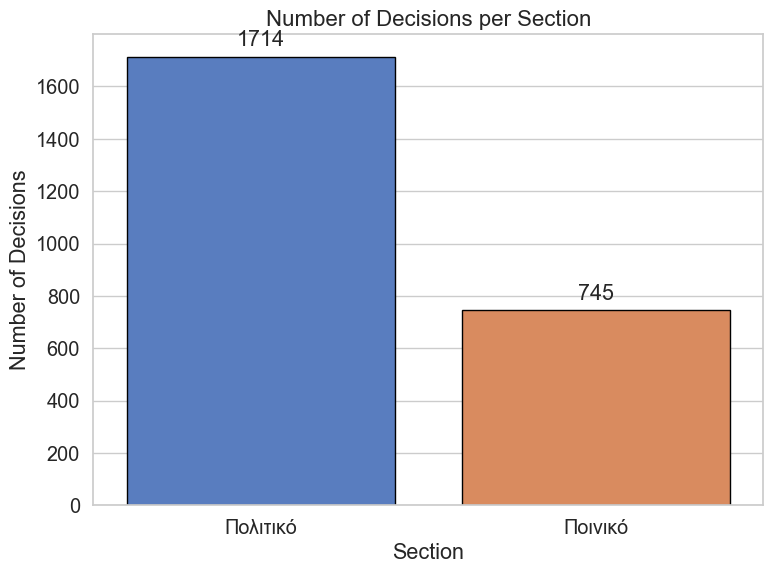

In [254]:
# --- Number of Decisions per Section ---
plt.figure(figsize=(8, 6))
sns.countplot(x='section_type', data=df, hue='section_type', palette='muted', dodge=False, legend=False, edgecolor='black')
plt.title('Number of Decisions per Section', fontsize=16)
plt.xlabel('Section')
plt.ylabel('Number of Decisions')
for container in plt.gca().containers:
    plt.bar_label(container, padding=5)
plt.tight_layout()
plt.show()

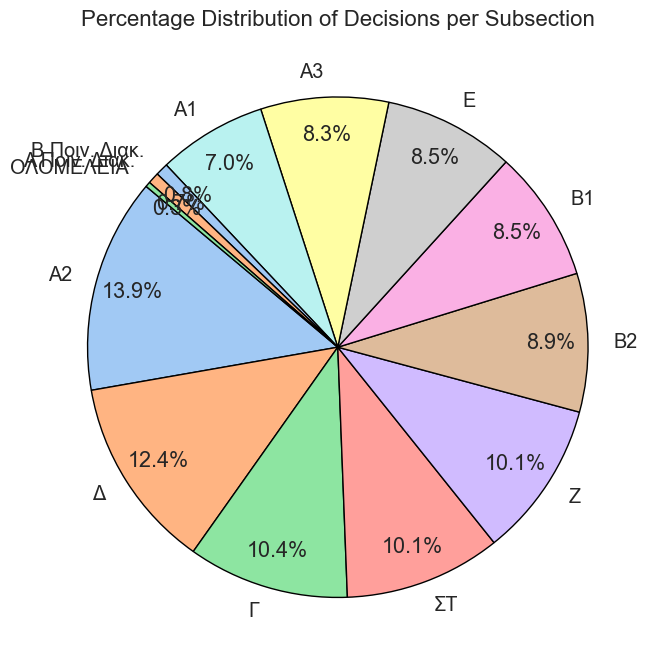

In [255]:
# --- Percentage Distribution of Subsections ---
plt.figure(figsize=(7, 7))
df['section_id'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
plt.title('Percentage Distribution of Decisions per Subsection', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

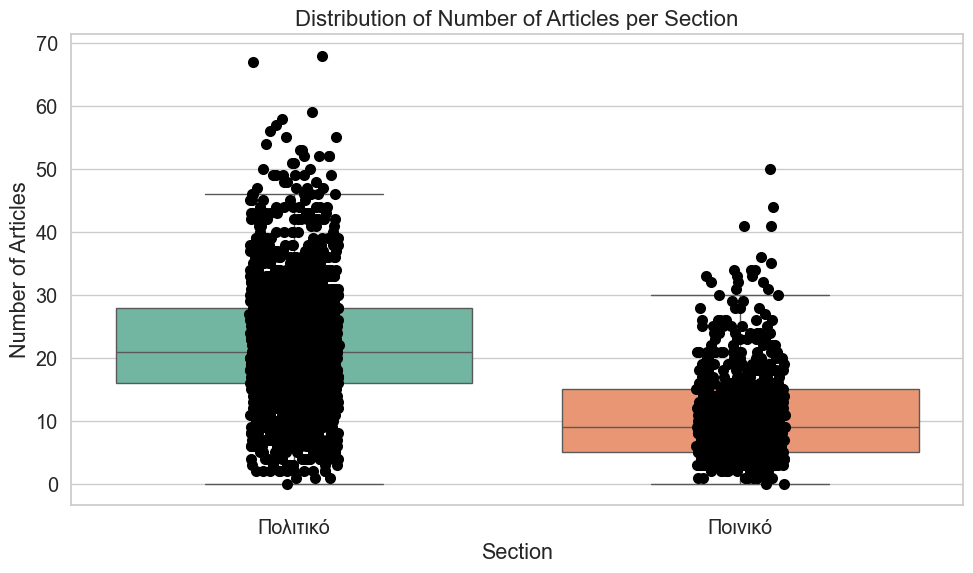

In [256]:
# --- Boxplot + Stripplot ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='section_type', y='num_articles_total', data=df, hue='section_type', palette='Set2', dodge=False, showfliers=False, legend=False)
sns.stripplot(x='section_type', y='num_articles_total', data=df, color='black', size=8, jitter=True)
plt.title('Distribution of Number of Articles per Section', fontsize=16)
plt.xlabel('Section')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

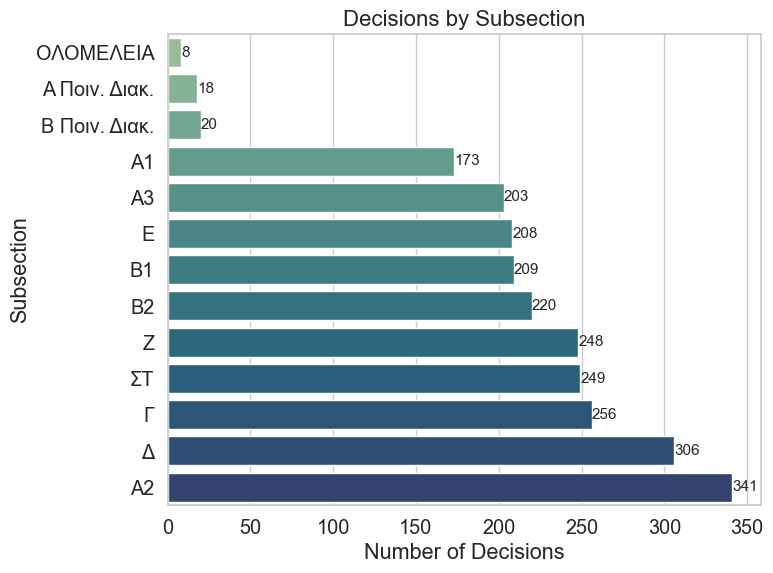

In [257]:
# --- Horizontal Barplot: Subsections ---
section_counts = df['section_id'].value_counts().sort_values()
section_df = pd.DataFrame({'Subsection': section_counts.index, 'Count': section_counts.values})
plt.figure(figsize=(8, 6))
sns.barplot(data=section_df, x='Count', y='Subsection', hue='Subsection', dodge=False, palette='crest', legend=False)
plt.title('Decisions by Subsection', fontsize=16)
plt.xlabel('Number of Decisions')
plt.ylabel('Subsection')
for i, v in enumerate(section_counts.values):
    plt.text(v + 0.1, i, str(v), va='center', fontsize=11)
plt.tight_layout()
plt.show()

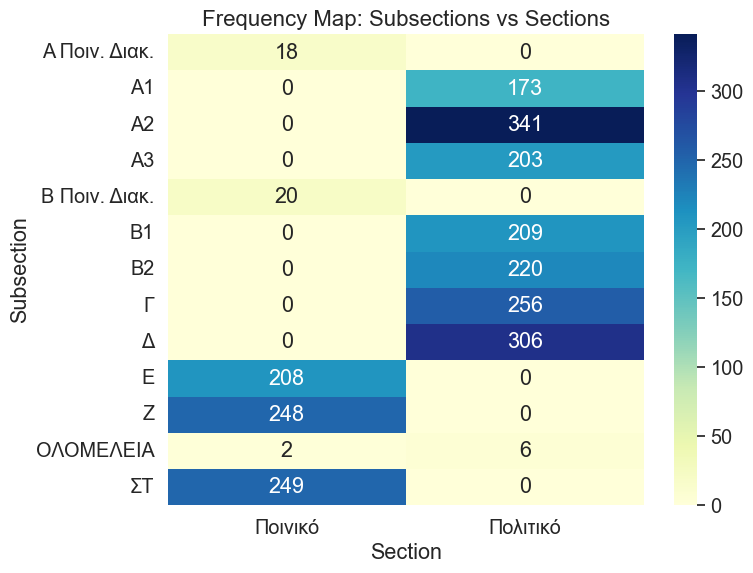

In [258]:
# --- Heatmap: Subsections vs Sections ---
pivot_table = df.pivot_table(index='section_id', columns='section_type', values='decision_number', aggfunc='count', fill_value=0)
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Frequency Map: Subsections vs Sections', fontsize=16)
plt.xlabel('Section')
plt.ylabel('Subsection')
plt.tight_layout()
plt.show()

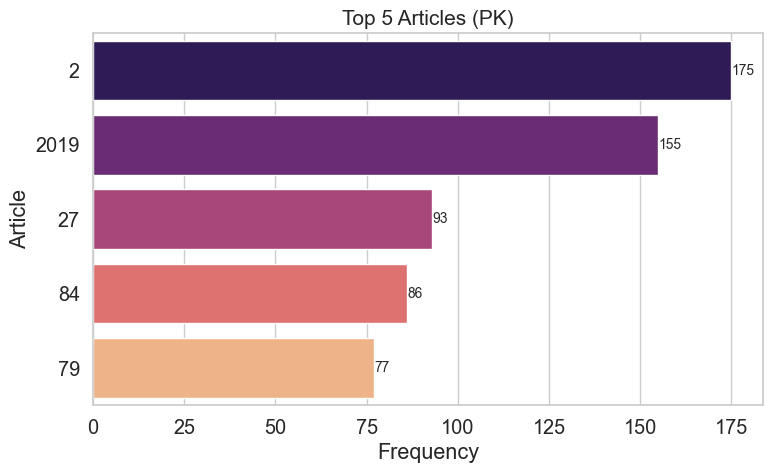

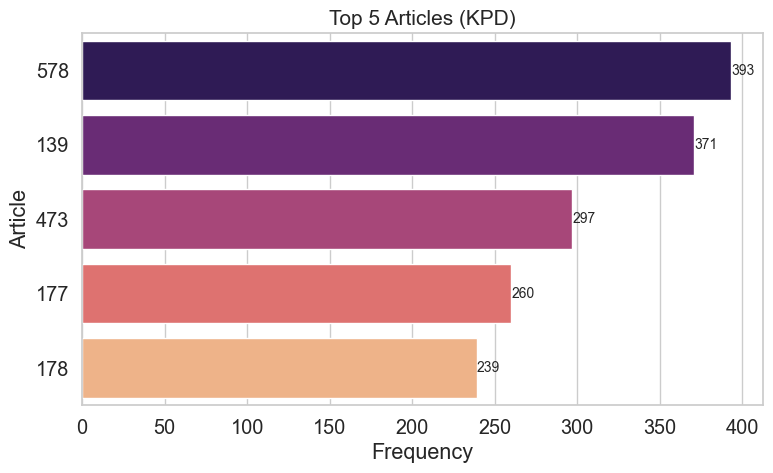

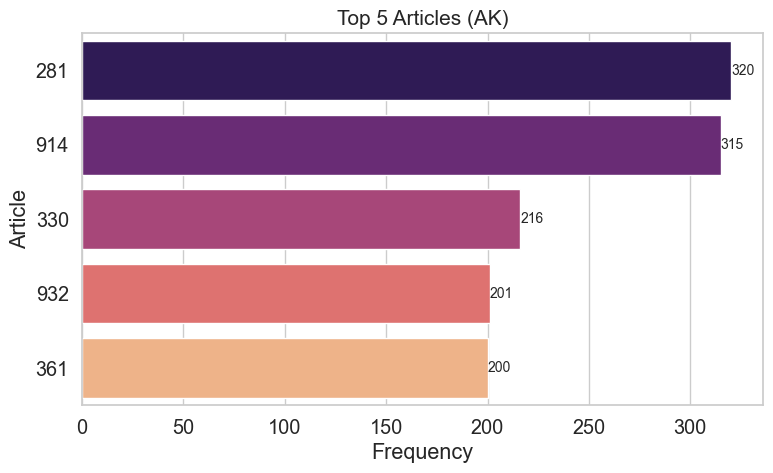

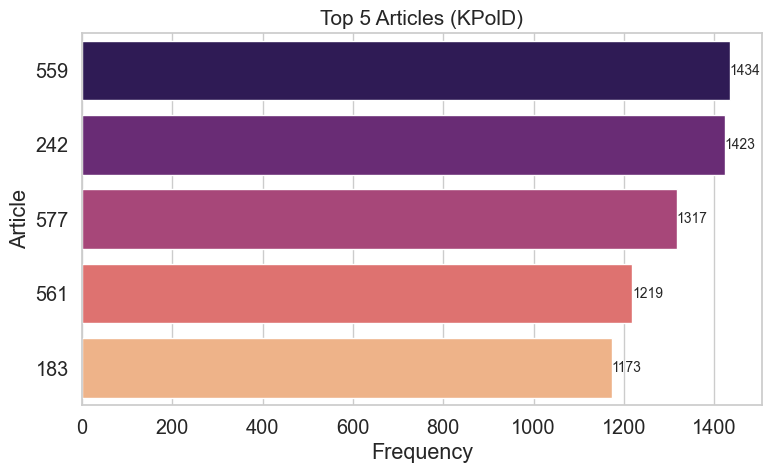

In [259]:
# --- Barplot: Top Articles ---
codes = {
    'PK': [art for sub in df['articles_pk'] for art in sub],
    'KPD': [art for sub in df['articles_kpd'] for art in sub],
    'AK': [art for sub in df['articles_ak'] for art in sub],
    'KPolD': [art for sub in df['articles_kpold'] for art in sub]
}
for code, articles_list in codes.items():
    if articles_list:
        counts = Counter(articles_list).most_common(5)
        art_df = pd.DataFrame(counts, columns=['Article', 'Count'])
        plt.figure(figsize=(8, 5))
        sns.barplot(data=art_df, x='Count', y='Article', hue='Article', dodge=False, palette='magma', legend=False)
        plt.title(f'Top 5 Articles ({code})', fontsize=15)
        plt.xlabel('Frequency')
        plt.ylabel('Article')
        for i, v in enumerate(art_df['Count']):
            plt.text(v + 0.1, i, str(v), va='center', fontsize=10)
        plt.tight_layout()
        plt.show()

In [ ]:
# Get decisions for 2009, 2013, 2018, the head of GreekLegalSum
years_to_check = [2009, 2013, 2018]

# Crawl 5 decisions from each year
comparison_links = {}
for year in years_to_check:
    comp_links, _ = get_decision_links(year=year, limit=50, save=False)
    comparison_links[year] = comp_links

# Print the crawled links
for year, links in comparison_links.items():
    print(f"\nYear: {year}")
    for link in links:
        print(link)

In [ ]:
random.seed(42)
# Example: Scrape 5 decisions from 2009
sample_2009_links = comparison_links[2009][6: random.randint(11, 48)]

results_2009 = []
for url in sample_2009_links:
    result = scrape_decision(url)
    results_2009.append(result)
    print(f"\n--- {url} ---")
    print("Law Thinking (sample):\n", result['law_thinking'][:500])

# 2013
sample_2013_links = comparison_links[2013][6: random.randint(11, 48)]

results_2013 = []
for url in sample_2013_links:
    result = scrape_decision(url)
    results_2013.append(result)
    print(f"\n--- {url} ---")
    print("Law Thinking (sample):\n", result['law_thinking'][:500])

# 2018
sample_2018_links = comparison_links[2018][6: random.randint(11, 48)]

results_2018 = []
for url in sample_2018_links:
    result = scrape_decision(url)
    results_2018.append(result)
    print(f"\n--- {url} ---")
    print("Law Thinking (sample):\n", result['law_thinking'][:500])

In [ ]:
# Show the first decision scraped from 2009
print("Scraped Decision Sample (2009):")
display(results_2009[0])

In [223]:
# Convert to DataFrames
df_2009 = pd.DataFrame(results_2009)
df_2013 = pd.DataFrame(results_2013)
df_2018 = pd.DataFrame(results_2018)

In [222]:
try:
    filename = "../data/greeklegalsum_dataset.csv"
    os.makedirs("../data", exist_ok=True)
    # Load from local file
    print("Attempting to load Greek Legal Sum dataset from local file...")
    greeklegalsum_df = pd.read_csv(filename)
except FileNotFoundError:
    # Load from HF
    print("File not found. Loading Greek Legal Sum dataset from HF instead...")
    greeklegalsum_df = pd.read_csv("hf://datasets/DominusTea/GreekLegalSum/hugginface_dataset.csv")
    print(f"Saving to local file {filename}")
    greeklegalsum_df.to_csv("filename", index=False)

Attempting to load Greek Legal Sum dataset from local file...


In [ ]:
def compare_decisions(greeklegalsum_df, loc, df, num):
    # Load GreekLegalSum decision
    greeklegal_text = greeklegalsum_df.loc[loc, 'text']
    
    # Load your scraped decision
    my_text = list(df[df['decision_number'] == num]['full_text_cleaned'])[0] # 75 is a decision from 2009
    
    # Compare scraped decision with GreekLegalSum
    print("GreekLegalSum TEXT:\n")
    print(greeklegal_text)
    print('--'*50)
    print("\nOur Crawled TEXT:\n")
    print(my_text)

In [204]:
compare_decisions(greeklegalsum_df, 6398, df_2009, 75)

GreekLegalSum TEXT:

Αριθμός 75/2009 

ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ

 ΣΤ' Ποινικό Τμήμα  

Συγκροτήθηκε από τους Δικαστές: Εμμανουήλ Καλούδη, Αντιπρόεδρο Αρείου Πάγου, Αιμιλία Λίτινα, Ανδρέα Τσόλια, Ιωάννη Παπουτσή - Εισηγητή και Ανδρέα Δουλγεράκη, Αρεοπαγίτες.
 
Συνήλθε σε δημόσια συνεδρίαση στο Κατάστημά του στις 14 Οκτωβρίου 2008, με την παρουσία του Αντεισαγγελέα του Αρείου Πάγου Παναγιώτη Νικολούδη (γιατί κωλύεται ο Εισαγγελέας) και της Γραμματέως Πελαγίας Λόζιου, για να δικάσει την αίτηση του αναιρεσείοντος - κατηγορουμένου Χ, που εκπροσωπήθηκε από τον πληρεξούσιο δικηγόρο του Γρηγόριο Δαρμάρο, περί αναιρέσεως της 4178/2007 αποφάσεως του Τριμελούς Εφετείου Θεσσαλονίκης. Με πολιτικώς ενάγοντα τον Ψ, που δεν παρέστη στο ακροατήριο και συγκατηγορούμενο Οδυσσέα Ματθαιόπουλο του Γεωργίου.  Το Τριμελές Εφετείο Θεσσαλονίκης, με την ως άνω απόφασή του διέταξε όσα λεπτομερώς αναφέρονται σ' αυτή και ο αναιρεσείων - κατηγορούμενος ζητεί την αναίρεση αυτής, για τους λόγους που αναφέρονται 

In [203]:
compare_decisions(greeklegalsum_df, 1363, df_2013, 20)

GreekLegalSum TEXT:

Αριθμός 20/2013 

ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ

B1' Πολιτικό Τμήμα 

Συγκροτήθηκε από τους Δικαστές: Σπυρίδωνα Ζιάκα, Αντιπρόεδρο Αρείου Πάγου, Βαρβάρα Κριτσωτάκη, Ανδρέα Δουλγεράκη, Νικόλαο Πάσσο και Δημήτριο Κόμη, Αρεοπαγίτες.
Συνήλθε σε δημόσια συνεδρίαση στο Κατάστημά του στις 4 Δεκεμβρίου 2012, με την παρουσία και του γραμματέα Αθανασίου Λιάπη, για να δικάσει μεταξύ:
Της αναιρεσείουσας: Ανώνυμης εταιρείας με την επωνυμία "ΤΡΑΠΕΖΑ ΤΗΣ ΕΛΛΑΔΟΣ ΑΕ", που εδρεύει στην ... και εκπροσωπείται νόμιμα, η οποία εκπροσωπήθηκε από τον πληρεξούσιο δικηγόρο της Θεμιστοκλή Μερσίνη.
Των αναιρεσιβλήτων: 1) Η. Ζ. του Α., κατοίκου ..., 2) Ν. Γ. του Α., κατοίκου ... και 3) Ε. Γ. του Α., κατοίκου ..., οι οποίοι παραστάθηκαν με τον πληρεξούσιο δικηγόρο τους Θεοφάνη Αρχιμανδρίτη. 
Η ένδικη διαφορά άρχισε με την από 10-6-2008 αγωγή των ήδη αναιρεσιβλήτων, που κατατέθηκε στο Μονομελές Πρωτοδικείο Αθηνών. Εκδόθηκαν οι αποφάσεις: 1369/2009 οριστική του ίδιου Δικαστηρίου και 3290/2010 τ